# Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt 

# Load Processed Dataset

In [6]:
df_games_final = pd.read_csv('final_mobile_game_dataset.csv')
df_games_final.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,EngagementScore,EngagementSegment
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19,115.47,Low
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08,213.29,Medium
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02,79.83,Low
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01,234.72,Medium
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05,152.30,Medium


# Data Type Conversion

In [8]:
df_games_final['LastPurchaseDate'] = pd.to_datetime(df_games_final['LastPurchaseDate'], format = '%Y-%m-%d') 

df_games_final['Age'] = df_games_final['Age'].astype('Int64')

df_games_final['FirstPurchaseDaysAfterInstall'] = df_games_final['FirstPurchaseDaysAfterInstall'].astype('Int64')

df_games_final['GameGenre'] = df_games_final['GameGenre'].astype('category')

In [9]:
df_games_final.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,EngagementScore,EngagementSegment
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28,Apple Pay,2025-03-19,115.47,Low
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18,Debit Card,2025-06-08,213.29,Medium
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30,Apple Pay,2025-06-02,79.83,Low
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9,Debit Card,2025-04-01,234.72,Medium
4,aa7eec14-4846-47b9-b879-9c98038cda04,37,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15,Paypal,2025-05-05,152.30,Medium


In [10]:
df_games_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   UserID                         3024 non-null   object        
 1   Age                            2964 non-null   Int64         
 2   Gender                         2964 non-null   object        
 3   Country                        2964 non-null   object        
 4   Device                         2964 non-null   object        
 5   GameGenre                      2964 non-null   category      
 6   SessionCount                   3024 non-null   int64         
 7   AverageSessionLength           3024 non-null   float64       
 8   SpendingSegment                3024 non-null   object        
 9   InAppPurchaseAmount            2888 non-null   float64       
 10  FirstPurchaseDaysAfterInstall  2888 non-null   Int64         
 11  PaymentMethod    

# Top Countries by Revenue

In [12]:
country_revenue = df_games_final.groupby('Country')['InAppPurchaseAmount']\
                   .sum().round(2).sort_values(ascending = False).head(10)

country_revenue

Country
India          34204.13
Afghanistan    20706.07
Bangladesh     17087.77
Canada         14358.44
South Korea    14115.99
Denmark        13901.79
Germany        13555.49
Italy          13549.10
Russia         12967.70
Japan          12357.39
Name: InAppPurchaseAmount, dtype: float64

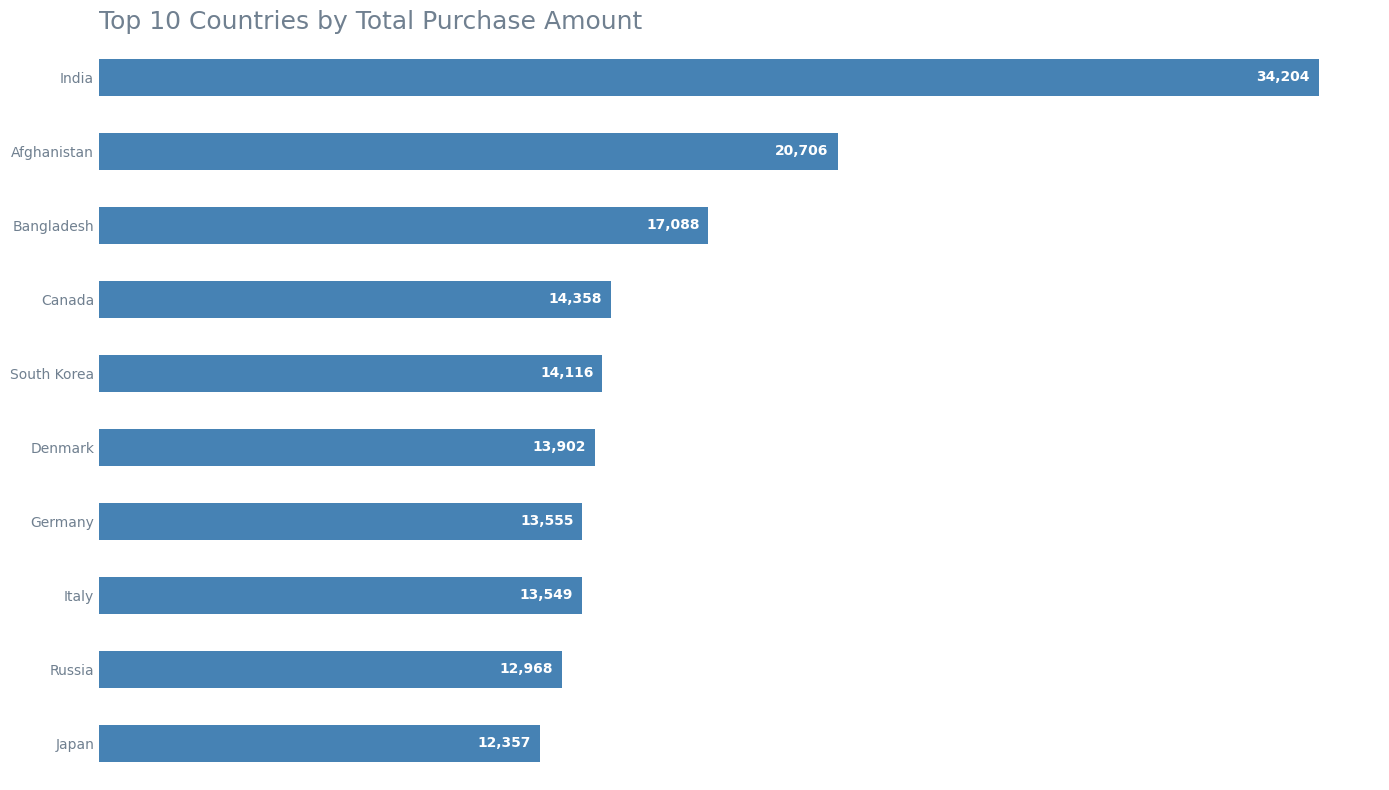

In [13]:
ax = country_revenue.plot(kind='barh', figsize = (14,8), color = 'steelblue')

plt.title('Top 10 Countries by Total Purchase Amount',
         fontsize = 18, pad = 8, loc='left', color = 'slategray')

plt.xlabel('')
plt.ylabel('')

plt.xticks([])
ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

ax.bar_label(
    ax.containers[0],
    padding = -45,
    fmt = '{:,.0f}',
    color = 'white',
    fontweight = 'bold')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

ax.invert_yaxis()

# not usable - plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.show()

# India generates the highest total in-app purchase amount among all countries in the dataset, followed by Afghanistan and Bangladesh.

# Top Countries By Average In-App Purchase

In [16]:
top_10_average_revenue_by_country = df_games_final.groupby('Country')['InAppPurchaseAmount']\
                               .mean().round(2).sort_values(ascending = False).head(10)
top_10_average_revenue_by_country

Country
Afghanistan    227.54
Bangladesh     172.60
Canada         149.57
Russia         147.36
India          146.17
South Korea    139.76
Sri Lanka      137.68
Denmark        137.64
Italy          127.82
Germany        125.51
Name: InAppPurchaseAmount, dtype: float64

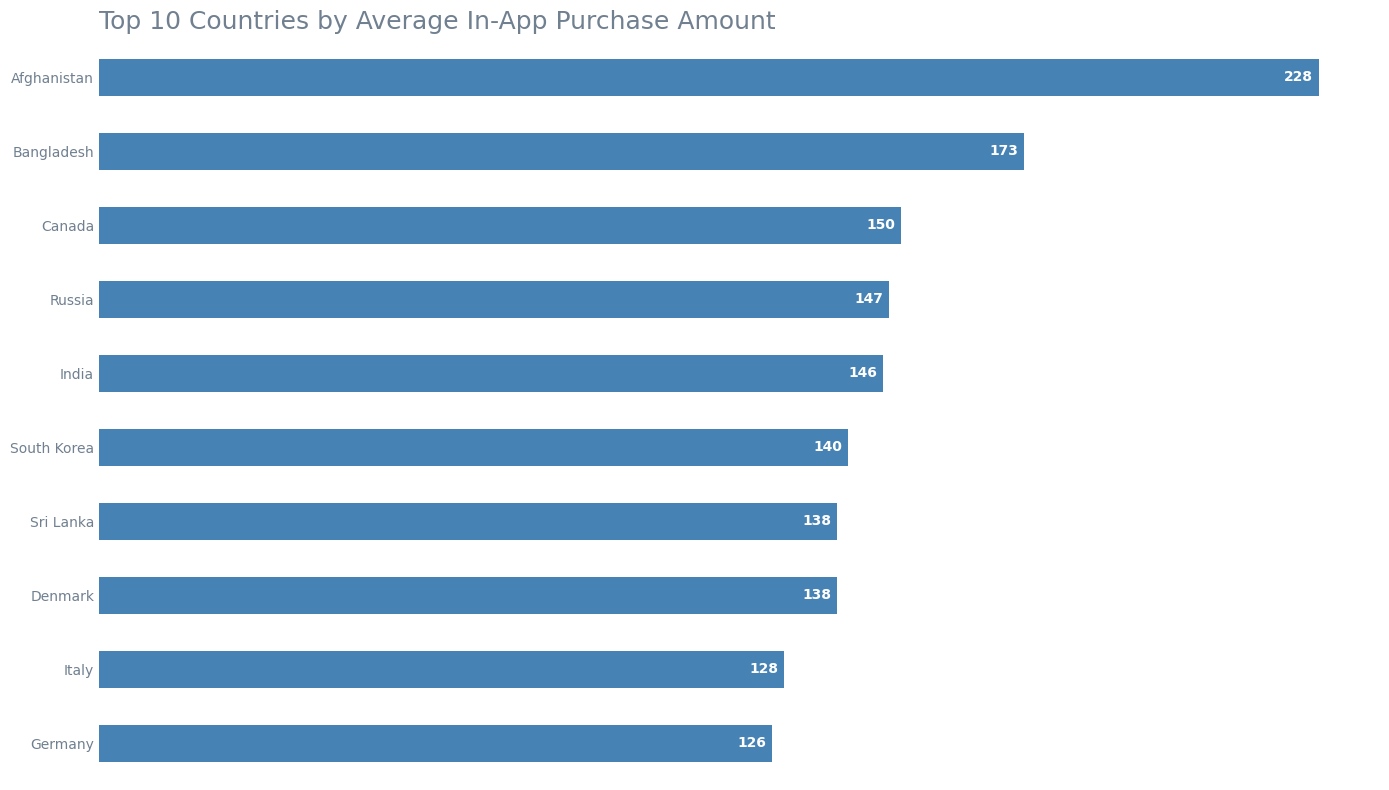

In [17]:
ax = top_10_average_revenue_by_country.plot(kind='barh', figsize = (14,8), color = 'steelblue')

plt.title('Top 10 Countries by Average In-App Purchase Amount',
         fontsize = 18, pad = 8, loc='left', color = 'slategray')

plt.xlabel('')
plt.ylabel('')

plt.xticks([])
ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

ax.bar_label(
    ax.containers[0],
    padding = -25,
    fmt = '{:,.0f}',
    color = 'white',
    fontweight = 'bold')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

ax.invert_yaxis()

plt.tight_layout()

plt.show()

# Unlike total purchase amount, average spending highlights countries where individual players spend more on average, regardless of the number of players.

In [19]:
purchase_summary = df_games_final['InAppPurchaseAmount'].describe().round(2).reset_index()

purchase_summary

,index,InAppPurchaseAmount
0,count,2888.00
1,mean,102.58
2,std,454.34
3,min,0.00
4,25%,5.99
5,50%,11.98
6,75%,17.76
7,max,4964.45


# The large gap between the median (€12) and the mean (€103), together with the high standard deviation (€454), indicates a strongly right-skewed distribution. This suggests that a relatively small number of high-spending players increase the average, while most players spend considerably less.

# Global Average Purchase Amount

In [22]:
global_average = df_games_final['InAppPurchaseAmount'].mean().round(2)

global_average

102.58

# Average In-App Purchase Amount by Country

In [24]:
average_revenue_by_country = (df_games_final.groupby('Country')['InAppPurchaseAmount']\
    .mean()
    .round(2)
    .sort_values(ascending=True)
    .reset_index()
)
average_revenue_by_country

,Country,InAppPurchaseAmount
0,Australia,40.59
1,Netherlands,46.11
2,France,46.56
3,Sweden,51.05
4,Saudi Arabia,54.29
5,Switzerland,54.97
6,Brazil,58.56
7,Egypt,69.17
8,China,70.07
9,Turkey,80.32


# Difference from Global Average

In [26]:
average_revenue_by_country['DifferenceFromGlobalAverage'] = (average_revenue_by_country['InAppPurchaseAmount'] - global_average)
average_revenue_by_country

,Country,InAppPurchaseAmount,DifferenceFromGlobalAverage
0,Australia,40.59,-61.99
1,Netherlands,46.11,-56.47
2,France,46.56,-56.02
3,Sweden,51.05,-51.53
4,Saudi Arabia,54.29,-48.29
5,Switzerland,54.97,-47.61
6,Brazil,58.56,-44.02
7,Egypt,69.17,-33.41
8,China,70.07,-32.51
9,Turkey,80.32,-22.26


# Average Spending vs Global Average

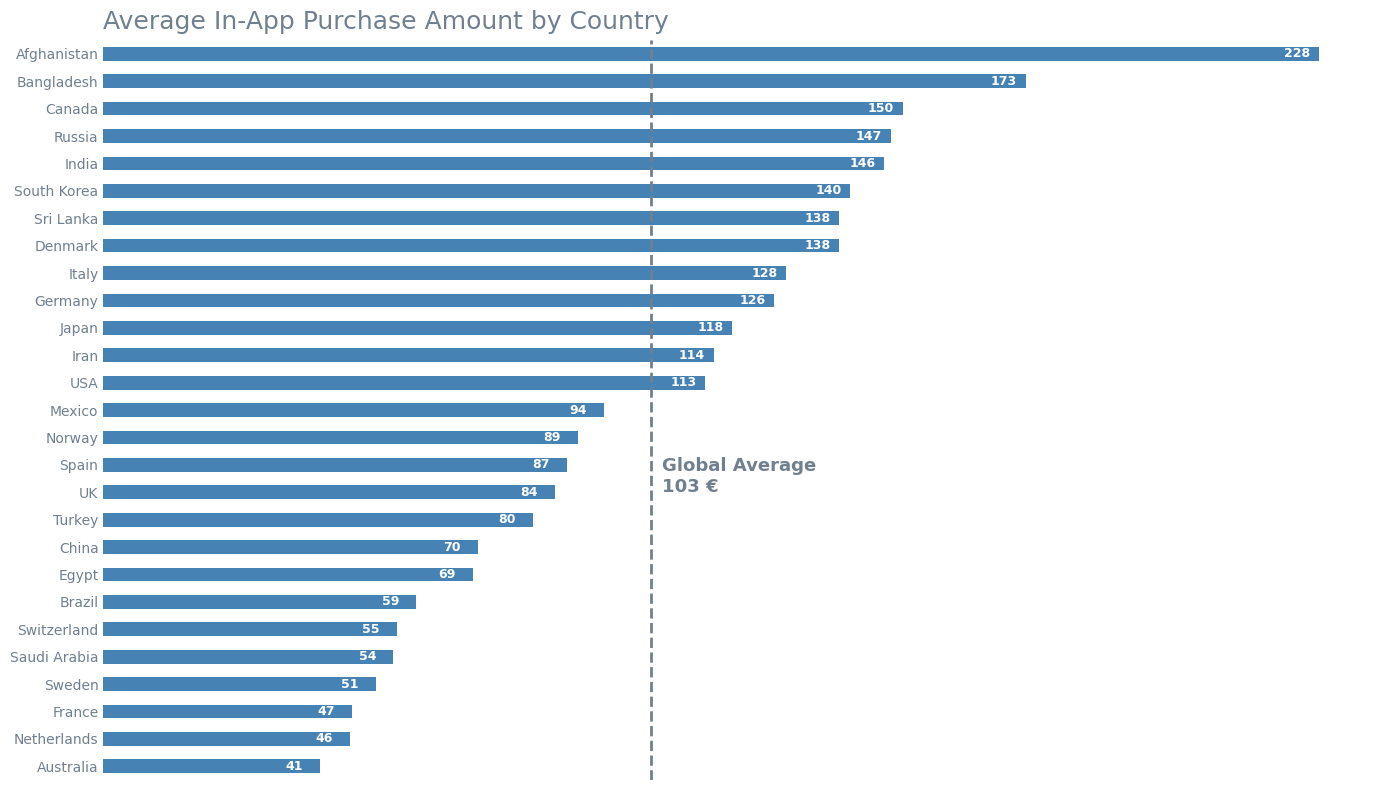

In [28]:
ax = average_revenue_by_country.plot(kind='barh', x='Country', y='InAppPurchaseAmount', figsize = (14,8), color = 'steelblue')

plt.axvline(x=global_average, color='slategray', linestyle='--',
            linewidth=2,
            label=f'Global Average ({global_average:.0f} €)')

plt.text(x=global_average + 2,
         y=10, s=f'Global Average\n{global_average:.0f} €',
         color='slategray',
         fontsize=13,
         fontweight = 'bold')

plt.title('Average In-App Purchase Amount by Country',
         fontsize = 18,
          pad = 8, 
          loc='left',
          color = 'slategray')

plt.xlabel('')
plt.ylabel('')

plt.xticks([])
ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

ax.bar_label(
    ax.containers[0],
    fontsize = 9,
    padding = -25,
    fmt = '{:,.0f}',
    color = 'white',
    fontweight = 'bold')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.legend().remove()

plt.tight_layout()

plt.show()

# Several countries display average purchase amounts below the global benchmark, even though previous EDA indicated relatively high engagement levels. This pattern deserves further investigation.

# Plotting Difference from Global Average (103€)

In [31]:
colors = []

for value in average_revenue_by_country['DifferenceFromGlobalAverage']:
    if value >= 0:
        colors.append('steelblue')
    else:
        colors.append('slategray')

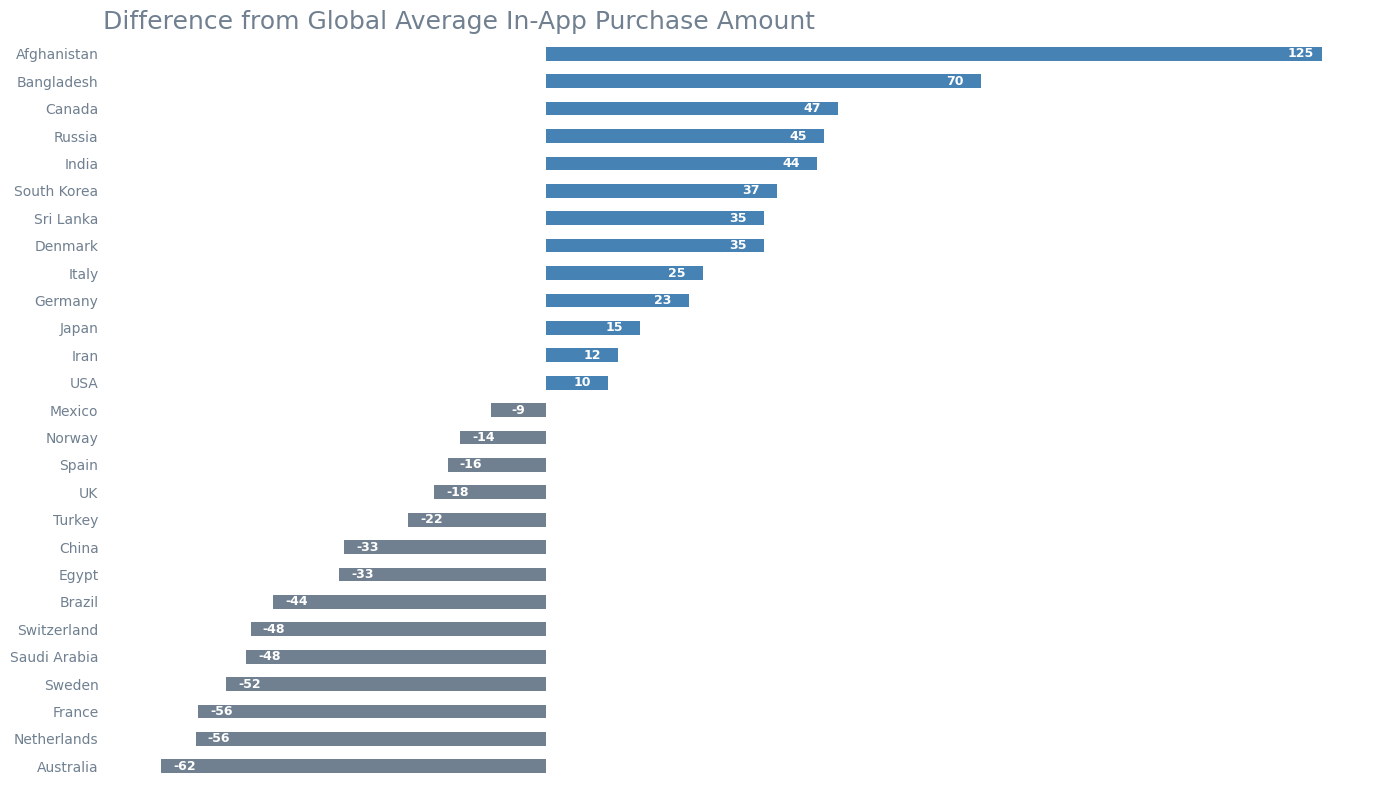

In [32]:
ax = average_revenue_by_country.plot(kind='barh', x='Country', y='DifferenceFromGlobalAverage', figsize = (14,8), color = colors)

plt.title('Difference from Global Average In-App Purchase Amount',
         fontsize = 18,
          pad = 8, 
          loc='left',
          color = 'slategray')

plt.xlabel('')
plt.ylabel('')

plt.xticks([])
ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

ax.bar_label(
    ax.containers[0],
    fontsize = 9,
    padding = -25,
    fmt = '{:,.0f}',
    color = 'white',
    fontweight = 'bold')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.legend().remove()

plt.tight_layout()

plt.show()

# Countries below the global average purchase amount do not necessarily generate less overall value. To investigate whether lower spending is associated with lower player engagement, the next step is to compare their Engagement Scores with the Global Average Engagement Score 

# Average Engagement Score by Country

In [35]:
average_engagement_score_by_country = (df_games_final.groupby('Country')['EngagementScore']\
    .mean()
    .round(2)
    .sort_values(ascending=True)
    .reset_index()
)
average_engagement_score_by_country

,Country,EngagementScore
0,Spain,181.44
1,China,184.04
2,Germany,185.01
3,Egypt,185.07
4,France,189.43
5,USA,192.32
6,Brazil,194.59
7,Iran,194.94
8,Japan,195.13
9,India,195.61


# Calculate the Global Average Engagement Score

In [37]:
average_engament_score = df_games_final['EngagementScore'].mean().round(2)

average_engament_score

201.96

# Identify Countries Below the Global Average In-App Purchase Amount

In [39]:
below_average_spending = average_revenue_by_country.loc[
    average_revenue_by_country['DifferenceFromGlobalAverage'] < 0,
    'Country']

below_average_spending

0        Australia
1      Netherlands
2           France
3           Sweden
4     Saudi Arabia
5      Switzerland
6           Brazil
7            Egypt
8            China
9           Turkey
10              UK
11           Spain
12          Norway
13          Mexico
Name: Country, dtype: object

# Highlight Countries Below the Global Average Purchase Amount

In [41]:
colors_engagement_countries = []

for country in average_engagement_score_by_country['Country']:
    if country in below_average_spending.values:
        colors_engagement_countries.append('steelblue')
    else:
        colors_engagement_countries.append('lightgray')

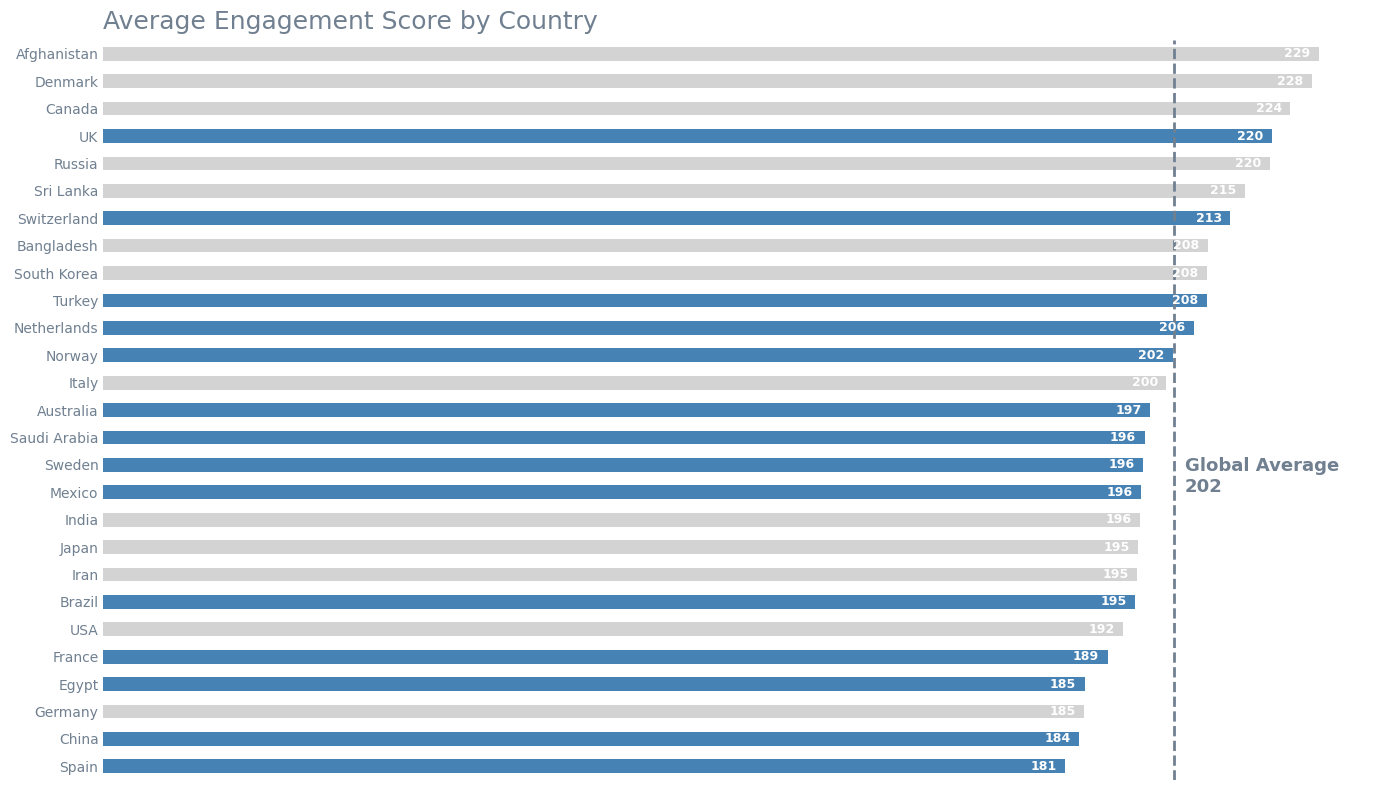

In [42]:
ax = average_engagement_score_by_country.plot(kind='barh', x='Country', y='EngagementScore', figsize = (14,8), color = colors_engagement_countries)

plt.axvline(x=average_engament_score, color='slategray', linestyle='--',
            linewidth=2,
            label=f'Global Average ({average_engament_score:.0f})')

plt.text(x=average_engament_score + 2,
         y=10, s=f'Global Average\n{average_engament_score:.0f}',
         color='slategray',
         fontsize=13,
         fontweight = 'bold')

plt.title('Average Engagement Score by Country',
         fontsize = 18,
          pad = 8, 
          loc='left',
          color = 'slategray')

plt.xlabel('')
plt.ylabel('')

plt.xticks([])
ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

ax.bar_label(
    ax.containers[0],
    fontsize = 9,
    padding = -25,
    fmt = '{:,.0f}',
    color = 'white',
    fontweight = 'bold')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.legend().remove()

plt.tight_layout()

plt.show()

# Several low-spending countries still show average or above-average Engagement Scores, suggesting that engagement alone does not explain monetization differences. Further investigation of the purchase funnel or recent A/B tests would be needed to identify potential barriers to conversion.

# Calculate Average Engagement Score by Game Genre

In [45]:
average_engagement_score_by_genres = (df_games_final.groupby('GameGenre', observed=True)['EngagementScore']\
    .mean()
    .round()
    .sort_values(ascending=True)
    .reset_index()
)
average_engagement_score_by_genres

,GameGenre,EngagementScore
0,Strategy,191.0
1,Racing,193.0
2,Sports,194.0
3,Action RPG,196.0
4,Casual,197.0
5,Sandbox,197.0
6,Fighting,200.0
7,Role Playing,203.0
8,MMORPG,204.0
9,MOBA,206.0


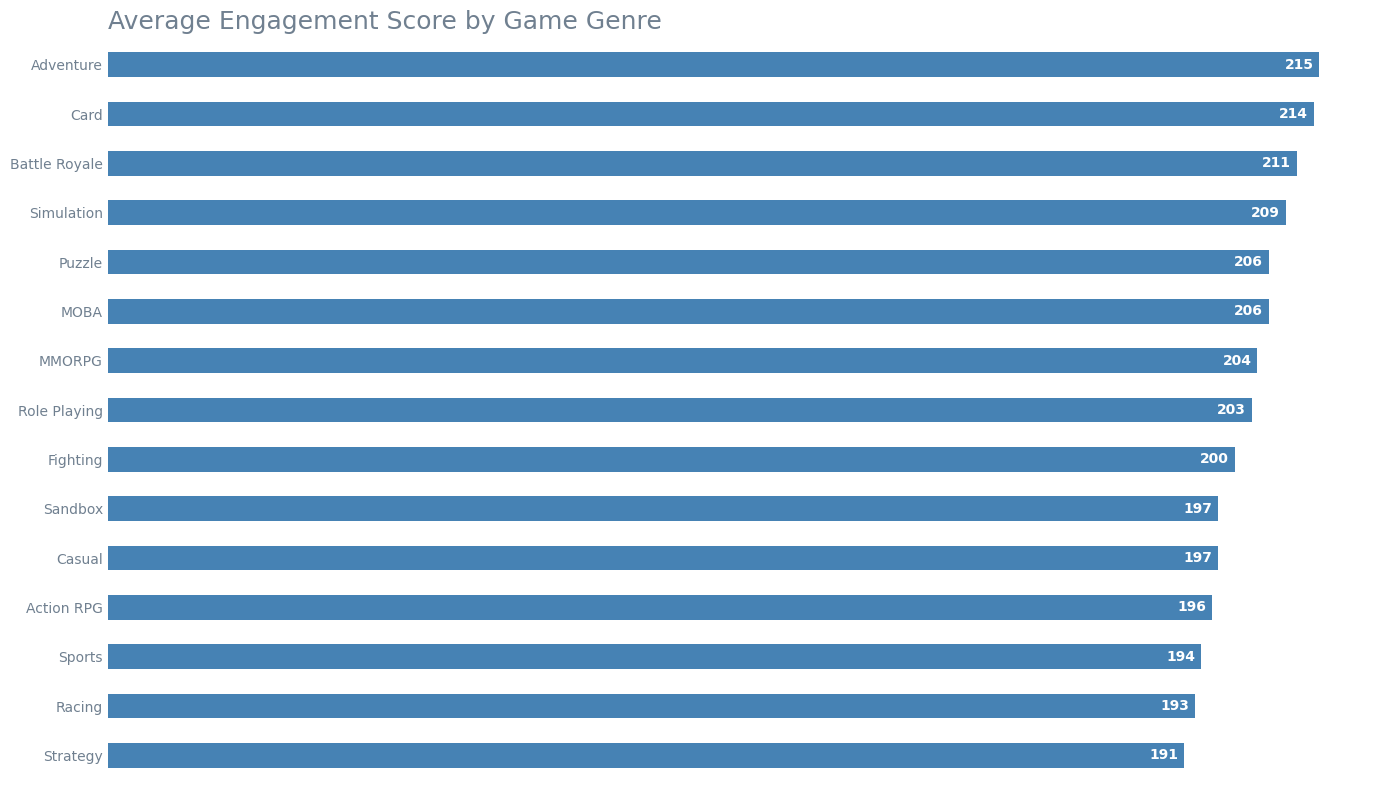

In [46]:
ax = average_engagement_score_by_genres.plot(kind='barh', x='GameGenre', y='EngagementScore', figsize = (14,8), color = 'steelblue')

plt.title('Average Engagement Score by Game Genre',
         fontsize = 18, pad = 8, loc='left', color = 'slategray')

plt.xlabel('')
plt.ylabel('')

plt.xticks([])
ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

ax.bar_label(
    ax.containers[0],
    padding = -25,
    fmt = '{:,.0f}',
    color = 'white',
    fontweight = 'bold')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

plt.legend().remove()

plt.show()

# Average Engagement Scores remain relatively consistent across all game genres, with only moderate differences between the highest- and lowest-performing genres. This suggests that player engagement is generally strong regardless of game genre.

# Average Session Count and Average Session Length remain remarkably consistent across all game genres. However, as shown in previous analyses, average In-App Purchase Amount varies substantially between genres. This suggests that differences in monetization are unlikely to be explained by player activity alone.

In [49]:
genres_by_purchase_amount = df_games_final.groupby('GameGenre', observed=True)[['SessionCount','InAppPurchaseAmount','AverageSessionLength']]\
                                .mean().round().sort_values(by ='InAppPurchaseAmount', ascending=False).reset_index()
genres_by_purchase_amount

,GameGenre,SessionCount,InAppPurchaseAmount,AverageSessionLength
0,Racing,10.0,160.0,20.0
1,Battle Royale,10.0,157.0,21.0
2,Strategy,10.0,143.0,19.0
3,Fighting,10.0,141.0,20.0
4,MOBA,10.0,140.0,21.0
5,MMORPG,10.0,98.0,20.0
6,Adventure,10.0,97.0,21.0
7,Role Playing,10.0,93.0,20.0
8,Simulation,10.0,85.0,20.0
9,Card,10.0,84.0,21.0


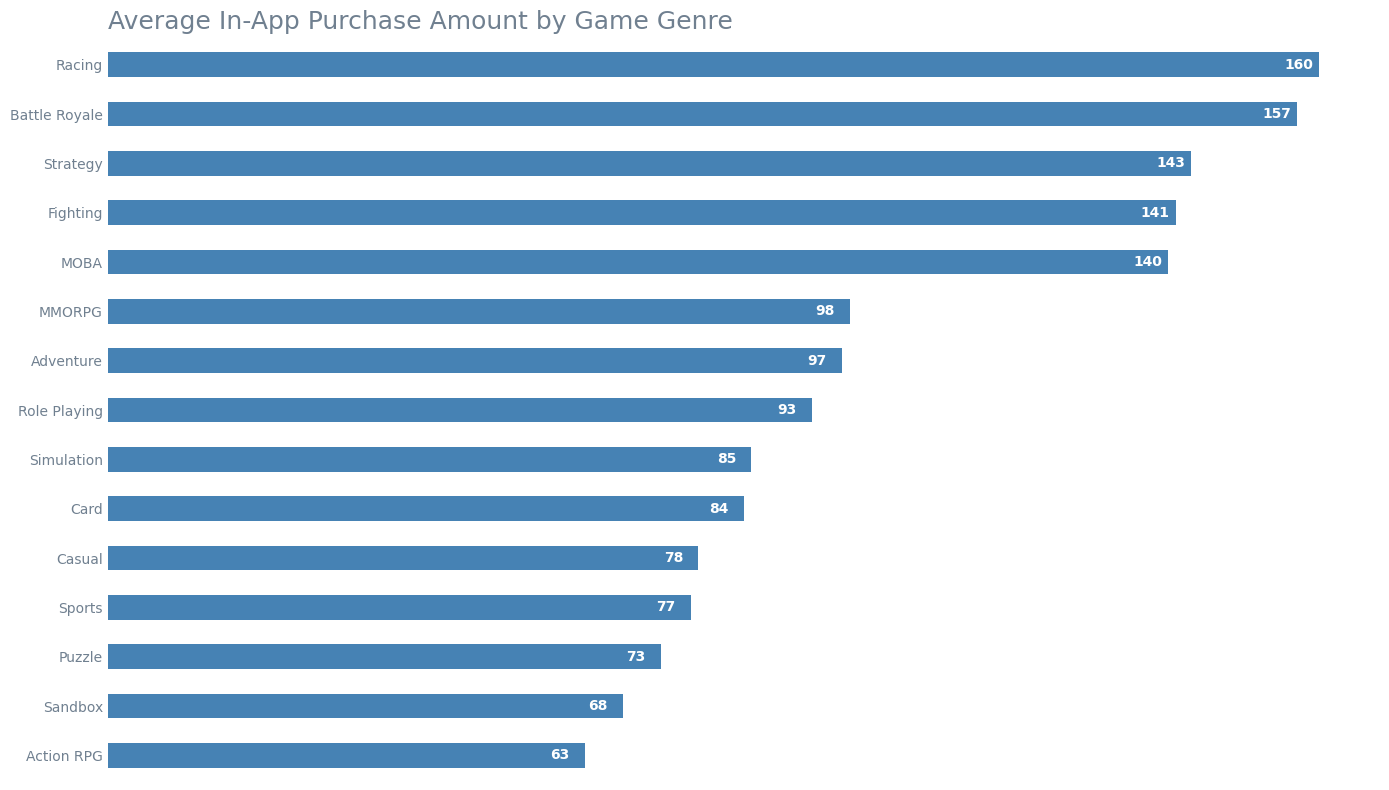

In [92]:
ax = genres_by_purchase_amount.plot(kind='barh', x='GameGenre', y='InAppPurchaseAmount', figsize = (14,8), color = 'steelblue')

plt.title('Average In-App Purchase Amount by Game Genre',
         fontsize = 18, pad = 8, loc='left', color = 'slategray')

plt.xlabel('')
plt.ylabel('')

plt.xticks([])
ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

ax.bar_label(
    ax.containers[0],
    padding = -25,
    fmt = '{:,.0f}',
    color = 'white',
    fontweight = 'bold')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

ax.invert_yaxis()

plt.tight_layout()

plt.legend().remove()

plt.show()



# Average in-app purchase amount varies considerably across game genres, providing a clear ranking of monetization performance. The final analysis investigates whether higher monetization is associated with higher player activity or whether these metrics diverge across genres.

### Identifying Countries Above Average Engagement Score 

In [53]:
countries_above_average = df_games_final.groupby('GameGenre', observed=True)['InAppPurchaseAmount']\
                                .mean().round().sort_values(ascending=False).head(5)
countries_above_average

GameGenre
Racing           160.0
Battle Royale    157.0
Strategy         143.0
Fighting         141.0
MOBA             140.0
Name: InAppPurchaseAmount, dtype: float64

# Calculating Global Average Engagement Score 

In [55]:
average_engagement_score = df_games_final['EngagementScore'].mean().round()
average_engagement_score

202.0

In [56]:
avg_engagement_score_by_genres = (df_games_final.groupby('GameGenre', observed=True)['EngagementScore']\
    .mean()
    .round()
    .sort_values(ascending=True)
    .reset_index()
)
avg_engagement_score_by_genres

,GameGenre,EngagementScore
0,Strategy,191.0
1,Racing,193.0
2,Sports,194.0
3,Action RPG,196.0
4,Casual,197.0
5,Sandbox,197.0
6,Fighting,200.0
7,Role Playing,203.0
8,MMORPG,204.0
9,MOBA,206.0


In [57]:
colors_above_engagement_countries = []

for game_genre in avg_engagement_score_by_genres['GameGenre']:
    if game_genre in countries_above_average.index:
        colors_above_engagement_countries.append('steelblue')
    else:
        colors_above_engagement_countries.append('lightgray')

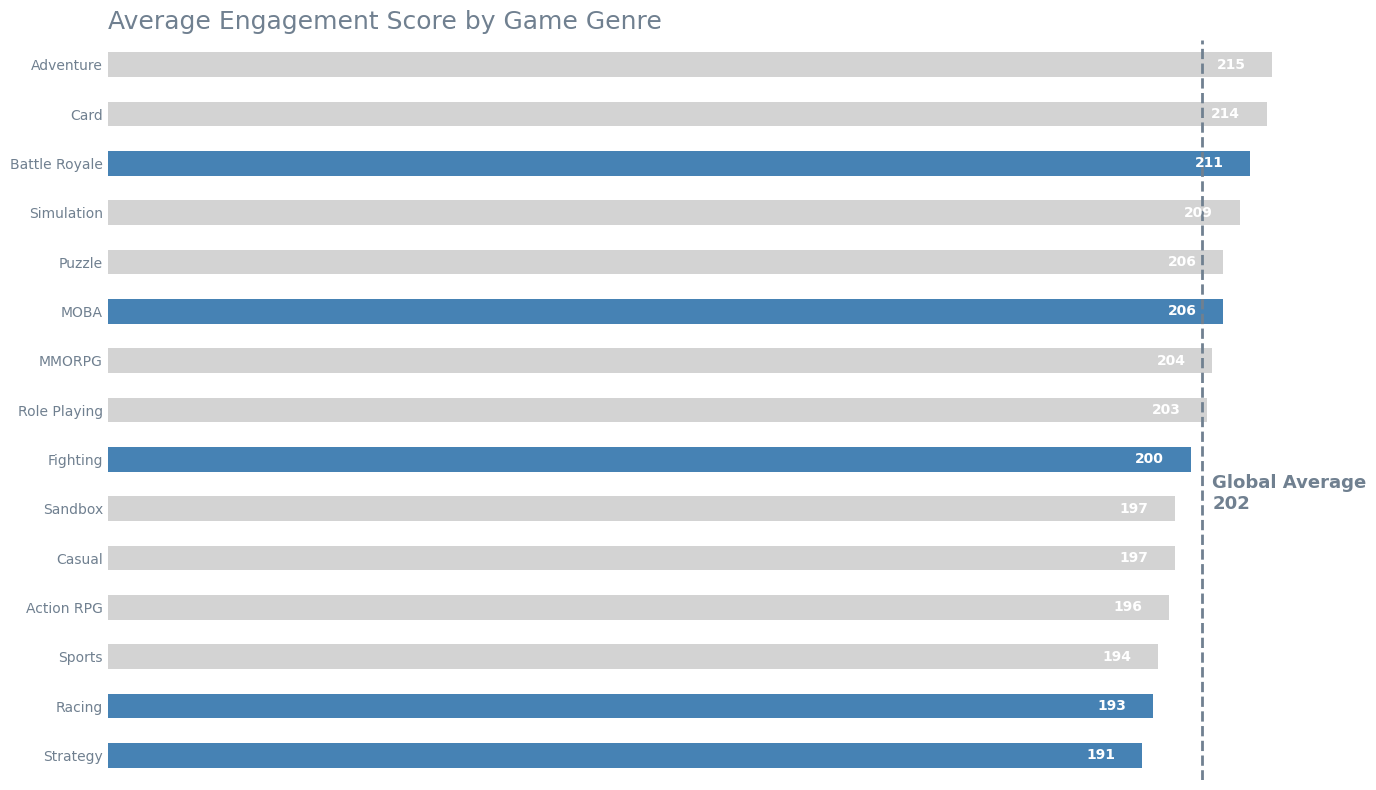

In [90]:
ax = avg_engagement_score_by_genres.plot(kind='barh', x='GameGenre', y='EngagementScore', figsize = (14,8), color = colors_above_engagement_countries)

plt.title('Average Engagement Score by Game Genre',
         fontsize = 18, pad = 8, loc='left', color = 'slategray')

plt.axvline(x=average_engagement_score, color='slategray', linestyle='--',
            linewidth=2,
            label=f'Global Average ({average_engagement_score:.0f})')

plt.text(x=average_engagement_score + 2,
         y=5, s=f'Global Average\n{average_engagement_score:.0f}',
         color='slategray',
         fontsize=13,
         fontweight = 'bold')

plt.xlabel('')
plt.ylabel('')

plt.xticks([])
ax.tick_params(
    axis = 'y',
    colors = 'slategray',
    length = 0)

ax.bar_label(
    ax.containers[0],
    padding = -40,
    color = 'white',
    fontweight = 'bold')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

plt.legend().remove()

plt.show()


# The top five game genres by average in-app purchase amount (highlighted in blue) are distributed both above and below the global average Engagement Score. This suggests that while player engagement remains relatively consistent across genres, differences in monetization are considerably larger. Therefore, engagement alone is unlikely to explain why some game genres generate higher average in-app purchase amounts than others.